In [1]:
import snapatac2 as snap
import numpy as np
import pandas as pd
# Set the environment variable to the desired cache path
import os
os.environ['SNAP_DATA_DIR'] = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Oligo'

snap.__version__

'2.6.4'

## data

In [2]:
data = snap.read_dataset("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hsc_raw.h5ads")
# data.obs[:].to_pandas()
data

AnnDataSet object with n_obs x n_vars = 109782 x 606219 backed at '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hsc_raw.h5ads'
contains 8 AnnData objects with keys: 'GW7', 'GW12', 'GW6', 'GW9', 'GW10', 'GW16', 'GW17', 'GW20'
    obs: 'sample'
    uns: 'AnnDataSet', 'reference_sequences'
    obsm: 'fragment_paired'

In [8]:
adata = data.to_adata()

In [10]:
data.close()

In [9]:
adata

AnnData object with n_obs × n_vars = 109782 × 606219
    obs: 'sample'
    uns: 'AnnDataSet', 'reference_sequences'
    obsm: 'fragment_paired'

In [11]:
# annotation
anno = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scanpy/Oligo/oligo_lineage.csv", index_col=0)
anno

,barcode2,sample2,celltype
AAACAGCCATCGTTCT-1-0,AAACAGCCATCGTTCT-1,GW6,NPC
AAACCGAAGGTCCACA-1-0,AAACCGAAGGTCCACA-1,GW6,NPC
AAAGGACGTGGACCTG-1-0,AAAGGACGTGGACCTG-1,GW6,NPC
AACCGCTCATGTCAGC-1-0,AACCGCTCATGTCAGC-1,GW6,NPC
AACCTCCTCAAGGACA-1-0,AACCTCCTCAAGGACA-1,GW6,NPC
...,...,...,...
TTTGTGGCAAGTCGCT-1-7,TTTGTGGCAAGTCGCT-1,GW20,dIPC
TTTGTGGCACGTAATT-1-7,TTTGTGGCACGTAATT-1,GW20,OPC
TTTGTGTTCCGCATGA-1-7,TTTGTGTTCCGCATGA-1,GW20,dIPC
TTTGTTGGTCACAAAT-1-7,TTTGTTGGTCACAAAT-1,GW20,OPC


In [12]:
adata = adata[adata.obs.index.isin(anno.index)]
adata.obs = adata.obs.join(anno)

In [ ]:
adata.obs = adata.obs[['sample2', 'barcode2', 'celltype']]

In [14]:
adata.obs['sample2'].value_counts()

sample2
GW16    3373
GW20    3177
GW17    1675
GW12     474
GW10     203
GW7      135
GW9      135
GW6      110
Name: count, dtype: int64

# Calculate spectral

In [21]:
snap.pp.select_features(adata, n_features=250000)
snap.tl.spectral(adata)
snap.tl.umap(adata)

2025-11-19 11:14:58 - INFO - Selected 250000 features.
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


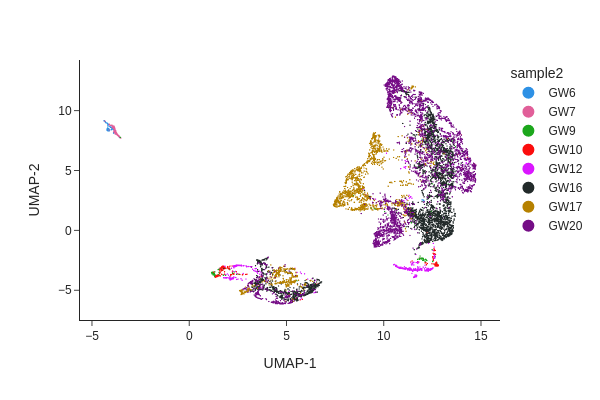

In [22]:
snap.pl.umap(adata, color="sample2", interactive=False)

# Batch correction

In [23]:
%%time
snap.pp.mnc_correct(adata, 
                    batch="sample2")

CPU times: user 2min 50s, sys: 5min 27s, total: 8min 18s
Wall time: 17.3 s


/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



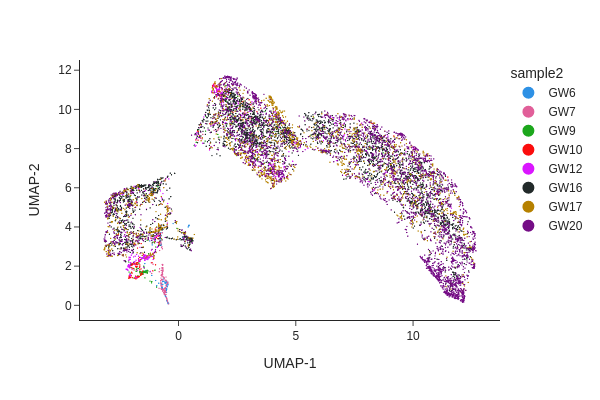

In [24]:
snap.tl.umap(adata, use_rep="X_spectral_mnn")
snap.pl.umap(adata, color="sample2", interactive=False)

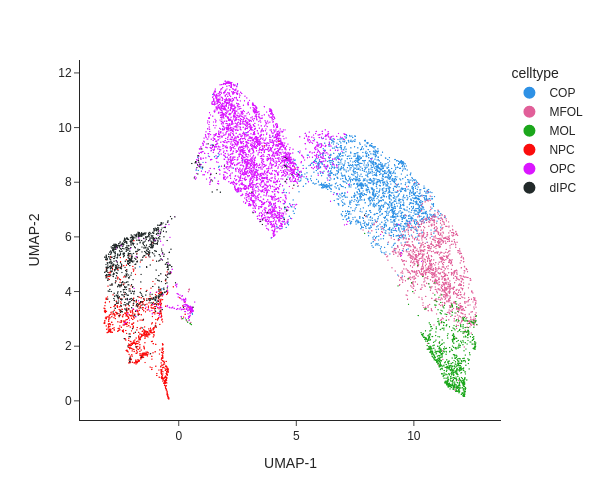

In [25]:
snap.pl.umap(adata, color="celltype", interactive=False, height=500)

In [3]:
adata.obs.to_csv('atac-meta.csv')

## Peak calling

In [26]:
%%time
snap.tl.macs3(adata, groupby='celltype', qvalue=0.01, blacklist='/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hg38-blacklist.v2.bed')

2025-11-19 11:19:48 - INFO - Exporting fragments...
2025-11-19 11:20:41 - INFO - Calling peaks...
100%|██████████| 6/6 [05:07<00:00, 51.27s/it]


CPU times: user 2min 19s, sys: 22.1 s, total: 2min 41s
Wall time: 6min 5s


In [27]:
adata

AnnData object with n_obs × n_vars = 9282 × 606219
    obs: 'sample2', 'barcode2', 'celltype'
    var: 'count', 'selected'
    uns: 'AnnDataSet', 'reference_sequences', 'spectral_eigenvalue', 'macs3'
    obsm: 'fragment_paired', 'X_spectral', 'X_umap', 'X_spectral_mnn'

In [28]:
adata.obsm['fragment_paired']

<9282x3088286401 sparse matrix of type '<class 'numpy.uint32'>'
	with 88479474 stored elements in Compressed Sparse Row format>

In [30]:
adata.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Oligo/oligo.h5ad')

In [2]:
adata = snap.read("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Oligo/oligo.h5ad", backed=None)
adata

AnnData object with n_obs × n_vars = 9282 × 606219
    obs: 'sample2', 'barcode2', 'celltype'
    var: 'count', 'selected'
    uns: 'AnnDataSet', 'macs3', 'reference_sequences', 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_spectral_mnn', 'X_umap', 'fragment_paired'

In [31]:
%%time
peaks = snap.tl.merge_peaks(adata.uns['macs3'], snap.genome.hg38)
peaks.shape

CPU times: user 1.17 s, sys: 237 ms, total: 1.41 s
Wall time: 1.4 s


(141240, 7)

In [32]:
chrom = peaks['Peaks']
chrom.to_pandas().to_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Oligo/cCREs.csv', index=False)

In [33]:
%%time
peak_mat = snap.pp.make_peak_matrix(adata, use_rep=peaks['Peaks'])
peak_mat

CPU times: user 2min 35s, sys: 2.72 s, total: 2min 37s
Wall time: 6.53 s


AnnData object with n_obs × n_vars = 9282 × 141240
    obs: 'sample2', 'barcode2', 'celltype'

In [ ]:
peak_mat.uns['reference_sequences'] = adata.uns['reference_sequences']
peak_mat.obsm['fragment_paired'] = adata.obsm['fragment_paired']

In [35]:
peak_mat.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Oligo/peak_mat.h5ad')

In [2]:
peak_mat = snap.read("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/Oligo/peak_mat.h5ad", backed=None)

In [3]:
%%time
marker_peaks = snap.tl.marker_regions(peak_mat, groupby='celltype', pvalue=0.05)

CPU times: user 4.6 s, sys: 114 ms, total: 4.71 s
Wall time: 4.72 s


In [4]:
marker_peaks

{'COP': Index(['chr1:1860955-1861456', 'chr1:1946601-1947102', 'chr1:2347118-2347619',
        'chr1:2390936-2391437', 'chr1:2836586-2837087', 'chr1:3424616-3425117',
        'chr1:3467690-3468191', 'chr1:4397207-4397708', 'chr1:4422749-4423250',
        'chr1:4469458-4469959',
        ...
        'chrX:150379591-150380092', 'chrX:151151629-151152130',
        'chrX:151705218-151705719', 'chrX:153593059-153593560',
        'chrX:153673660-153674161', 'chrX:153751507-153752008',
        'chrX:153829472-153829973', 'chrX:154486419-154486920',
        'chrY:5130629-5131130', 'chrY:15540663-15541164'],
       dtype='object', length=5936),
 'MFOL': Index(['chr1:935067-935568', 'chr1:966785-967286', 'chr1:985189-985690',
        'chr1:1173831-1174332', 'chr1:1398672-1399173', 'chr1:1407067-1407568',
        'chr1:1573960-1574461', 'chr1:1891429-1891930', 'chr1:2160754-2161255',
        'chr1:2227578-2228079',
        ...
        'chrX:153599085-153599586', 'chrX:153610828-153611329',
       

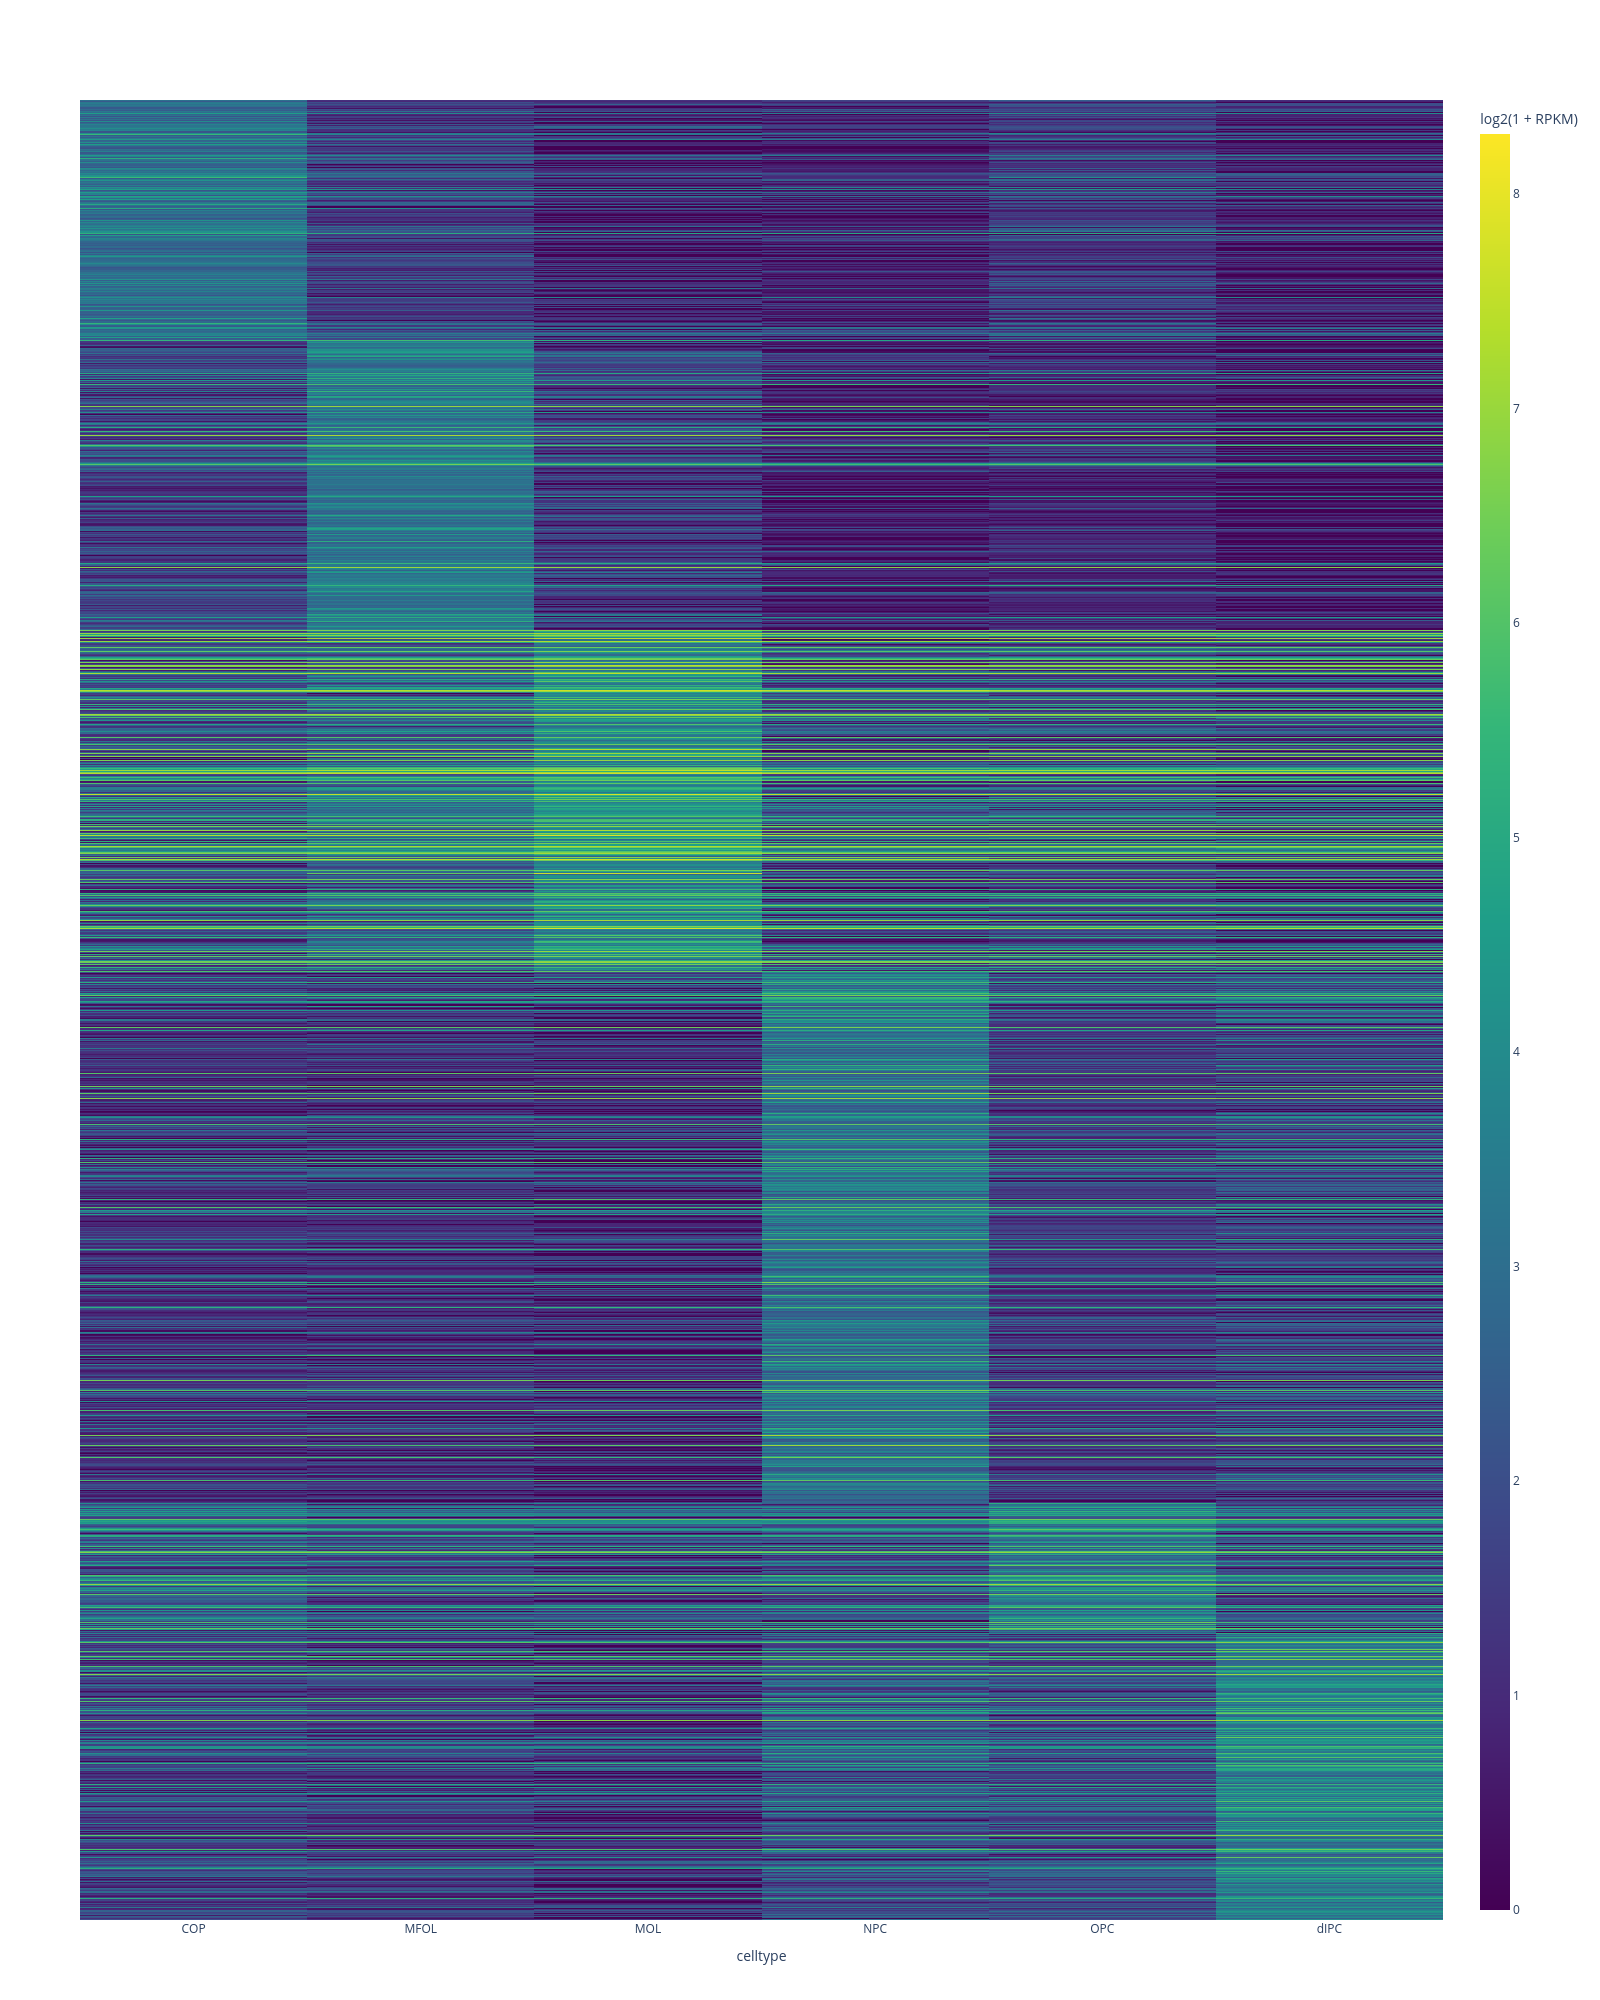

In [5]:
snap.pl.regions(peak_mat, 
                groupby='celltype', 
                peaks=marker_peaks, 
                width = 1600, 
                height = 2000,
                interactive=False)

In [6]:
data = []

# 遍历marker_peaks字典
for cell_type, peaks in marker_peaks.items():
    # 对于每个细胞类型的每个peak，添加到数据列表中
    for peak in peaks:
        data.append([peak, cell_type])

# 创建DataFrame
dar = pd.DataFrame(data, columns=['peak', 'cell_type'])

# 保存为CSV文件
dar.to_csv('oligo_marker_celltype_dar.csv', index=False)